In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
df

,no,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [4]:
df.head()

,no,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 23486
Number of columns: 11


In [6]:
print("Dataset columns:")

for column in df.columns:
    print("-", column)

Dataset columns:
- no
- Clothing ID
- Age
- Title
- Review Text
- Rating
- Recommended IND
- Positive Feedback Count
- Division Name
- Department Name
- Class Name


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   no                       23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB


In [8]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
no                            0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no,23486.0,11742.500000,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
Clothing ID,23486.0,918.118709,203.298980,0.0,861.00,936.0,1078.00,1205.0
Age,23486.0,43.198544,12.279544,18.0,34.00,41.0,52.00,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.00,5.0,5.00,5.0
Recommended IND,23486.0,0.822362,0.382216,0.0,1.00,1.0,1.00,1.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.00,1.0,3.00,122.0


In [10]:
sns.set_style("whitegrid")

print("Visualization libraries imported successfully")

Visualization libraries imported successfully


In [11]:
scaling_features = [
    "Age",
    "Positive Feedback Count"
]

df_scaling = df[scaling_features].copy()

print("Selected scaling features:")
print(scaling_features)

df_scaling.head()

Selected scaling features:
['Age', 'Positive Feedback Count']


,Age,Positive Feedback Count
0,33,0
1,34,4
2,60,0
3,50,0
4,47,6


In [12]:
print("Selected data shape:", df_scaling.shape)

print("\nMissing values:")
print(df_scaling.isnull().sum())

Selected data shape: (23486, 2)

Missing values:
Age                        0
Positive Feedback Count    0
dtype: int64


In [13]:
original_summary = df_scaling.describe().T

original_summary

,count,mean,std,min,25%,50%,75%,max
Age,23486.0,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0


In [14]:
skewness_results = df_scaling.skew().to_frame(
    name="Skewness"
)

skewness_results

,Skewness
Age,0.525615
Positive Feedback Count,6.472998


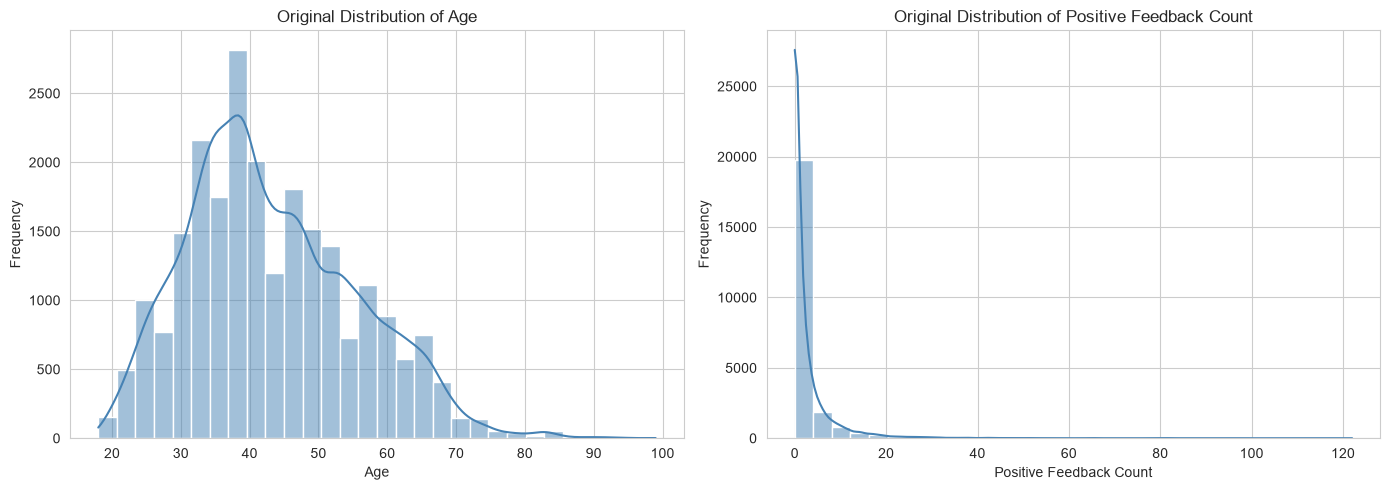

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, column in enumerate(scaling_features):
    sns.histplot(
        data=df_scaling,
        x=column,
        bins=30,
        kde=True,
        ax=axes[i],
        color="steelblue"
    )

    axes[i].set_title(f"Original Distribution of {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

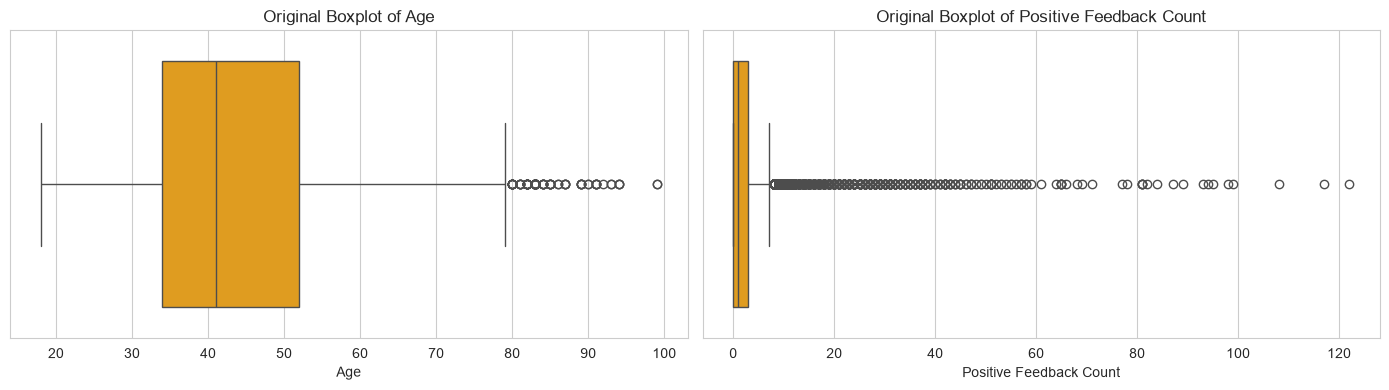

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, column in enumerate(scaling_features):
    sns.boxplot(
        x=df_scaling[column],
        ax=axes[i],
        color="orange"
    )

    axes[i].set_title(f"Original Boxplot of {column}")

plt.tight_layout()
plt.show()

In [17]:
outlier_results = []

for column in scaling_features:
    q1 = df_scaling[column].quantile(0.25)
    q3 = df_scaling[column].quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_count = (
        (df_scaling[column] < lower_limit) |
        (df_scaling[column] > upper_limit)
    ).sum()

    outlier_results.append({
        "Feature": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Outlier Count": outlier_count
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Limit,Upper Limit,Outlier Count
0,Age,34.0,52.0,18.0,7.0,79.0,109
1,Positive Feedback Count,0.0,3.0,3.0,-4.5,7.5,2147


In [18]:
X = df[
    [
        "Age",
        "Positive Feedback Count"
    ]
].copy()

X.head()

,Age,Positive Feedback Count
0,33,0
1,34,4
2,60,0
3,50,0
4,47,6


In [19]:
y = df["Recommended IND"].copy()

y.head()

0    1
1    1
2    0
3    1
4    1
Name: Recommended IND, dtype: int64

In [20]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (23486, 2)
Target shape: (23486,)


In [21]:
target_distribution = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage": y.value_counts(normalize=True).mul(100).round(2)
})

target_distribution

,Count,Percentage
Recommended IND,,
1,19314,82.24
0,4172,17.76


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (18788, 2)
X_test shape : (4698, 2)
y_train shape: (18788,)
y_test shape : (4698,)


In [24]:
split_distribution = pd.DataFrame({
    "Training Percentage":
        y_train.value_counts(normalize=True).mul(100).round(2),

    "Testing Percentage":
        y_test.value_counts(normalize=True).mul(100).round(2)
})

split_distribution

,Training Percentage,Testing Percentage
Recommended IND,,
1,82.24,82.23
0,17.76,17.77


In [25]:
print("Training feature missing values:")
print(X_train.isnull().sum())

print("\nTesting feature missing values:")
print(X_test.isnull().sum())

Training feature missing values:
Age                        0
Positive Feedback Count    0
dtype: int64

Testing feature missing values:
Age                        0
Positive Feedback Count    0
dtype: int64


In [28]:
minmax_scaler = MinMaxScaler()
X_train_minmax_array = minmax_scaler.fit_transform(X_train)
X_test_minmax_array = minmax_scaler.transform(X_test)

In [29]:
X_train_minmax = pd.DataFrame(
    X_train_minmax_array,
    columns=X_train.columns,
    index=X_train.index
)

X_test_minmax = pd.DataFrame(
    X_test_minmax_array,
    columns=X_test.columns,
    index=X_test.index
)

X_train_minmax.head()

,Age,Positive Feedback Count
22653,0.382716,0.000000
6939,0.209877,0.051282
2679,0.382716,0.000000
17164,0.123457,0.000000
714,0.395062,0.000000


In [30]:
minmax_parameters = pd.DataFrame({
    "Feature": X_train.columns,
    "Training Minimum": minmax_scaler.data_min_,
    "Training Maximum": minmax_scaler.data_max_,
    "Training Range": minmax_scaler.data_range_
})

minmax_parameters

,Feature,Training Minimum,Training Maximum,Training Range
0,Age,18.0,99.0,81.0
1,Positive Feedback Count,0.0,117.0,117.0


In [31]:
minmax_range_check = pd.DataFrame({
    "Scaled Minimum": X_train_minmax.min(),
    "Scaled Maximum": X_train_minmax.max()
})

minmax_range_check

,Scaled Minimum,Scaled Maximum
Age,0.0,1.0
Positive Feedback Count,0.0,1.0


In [32]:
print("Test data minimum:")
print(X_test_minmax.min())

print("\nTest data maximum:")
print(X_test_minmax.max())

Test data minimum:
Age                        0.0
Positive Feedback Count    0.0
dtype: float64

Test data maximum:
Age                        0.925926
Positive Feedback Count    1.042735
dtype: float64


In [33]:
original_train_summary = X_train.describe().T[
    ["mean", "std", "min", "50%", "max"]
].add_prefix("Original ")

minmax_train_summary = X_train_minmax.describe().T[
    ["mean", "std", "min", "50%", "max"]
].add_prefix("MinMax ")

minmax_comparison = pd.concat(
    [original_train_summary, minmax_train_summary],
    axis=1
)

minmax_comparison

,Original mean,Original std,Original min,Original 50%,Original max,MinMax mean,MinMax std,MinMax min,MinMax 50%,MinMax max
Age,43.174367,12.275373,18.0,41.0,99.0,0.310795,0.151548,0.0,0.283951,1.0
Positive Feedback Count,2.547796,5.651950,0.0,1.0,117.0,0.021776,0.048307,0.0,0.008547,1.0


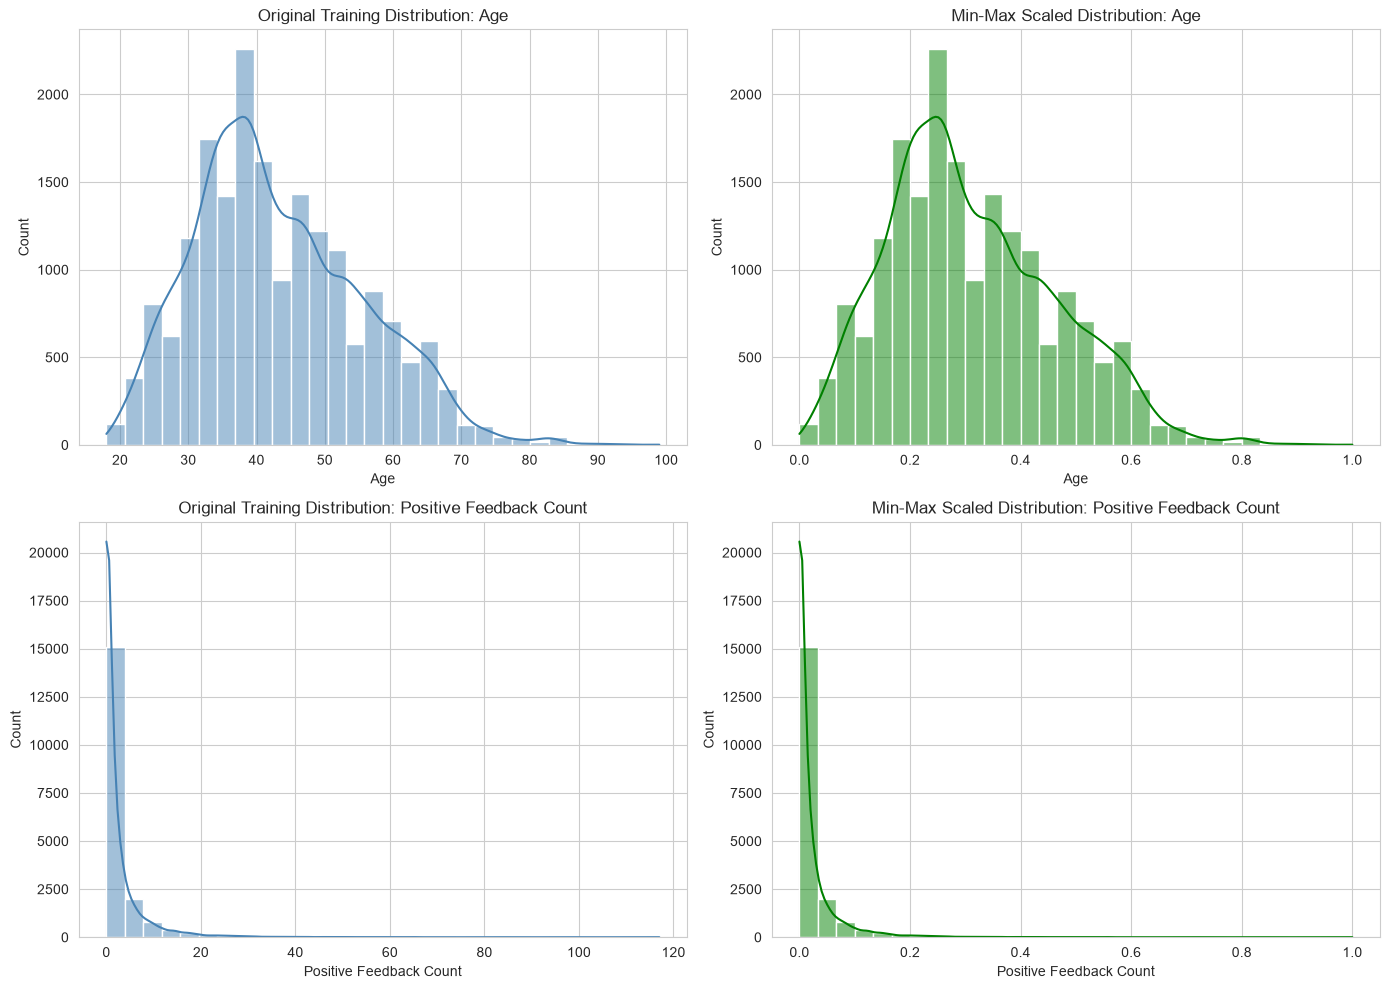

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, column in enumerate(X_train.columns):
    sns.histplot(
        X_train[column],
        bins=30,
        kde=True,
        ax=axes[i, 0],
        color="steelblue"
    )

    axes[i, 0].set_title(f"Original Training Distribution: {column}")

    sns.histplot(
        X_train_minmax[column],
        bins=30,
        kde=True,
        ax=axes[i, 1],
        color="green"
    )

    axes[i, 1].set_title(f"Min-Max Scaled Distribution: {column}")

plt.tight_layout()
plt.show()

In [35]:
minmax_skewness_comparison = pd.DataFrame({
    "Original Skewness": X_train.skew(),
    "MinMax Skewness": X_train_minmax.skew()
})

minmax_skewness_comparison

,Original Skewness,MinMax Skewness
Age,0.538471,0.538471
Positive Feedback Count,6.117234,6.117234


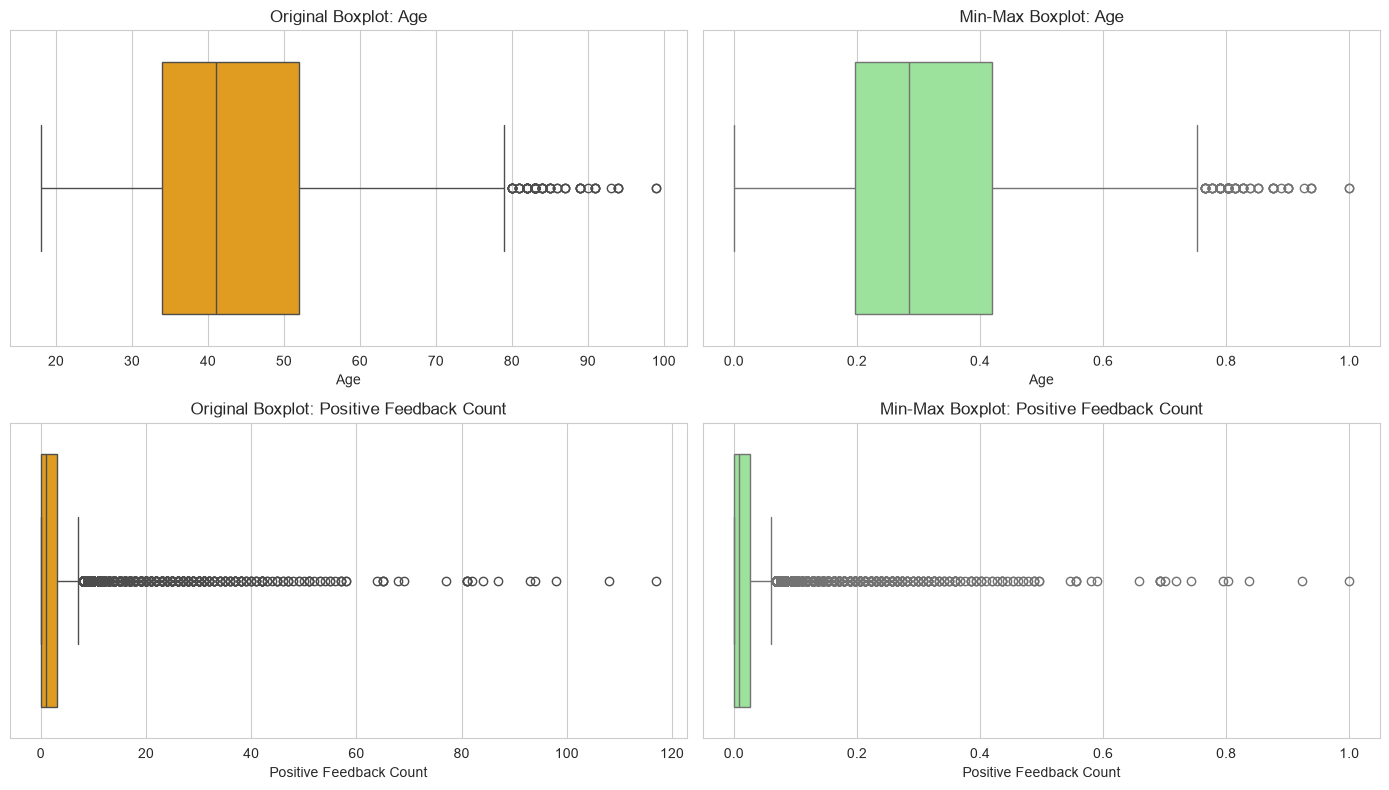

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, column in enumerate(X_train.columns):
    sns.boxplot(
        x=X_train[column],
        ax=axes[i, 0],
        color="orange"
    )
    axes[i, 0].set_title(f"Original Boxplot: {column}")

    sns.boxplot(
        x=X_train_minmax[column],
        ax=axes[i, 1],
        color="lightgreen"
    )
    axes[i, 1].set_title(f"Min-Max Boxplot: {column}")

plt.tight_layout()
plt.show()

In [38]:
standard_scaler = StandardScaler()
X_train_standard_array = standard_scaler.fit_transform(X_train)
X_test_standard_array = standard_scaler.transform(X_test)

In [39]:
X_train_standard = pd.DataFrame(
    X_train_standard_array,
    columns=X_train.columns,
    index=X_train.index
)

X_test_standard = pd.DataFrame(
    X_test_standard_array,
    columns=X_test.columns,
    index=X_test.index
)

X_train_standard.head()

,Age,Positive Feedback Count
22653,0.474592,-0.450794
6939,-0.665934,0.610815
2679,0.474592,-0.450794
17164,-1.236196,-0.450794
714,0.556058,-0.450794


In [40]:
standard_parameters = pd.DataFrame({
    "Feature": X_train.columns,
    "Training Mean": standard_scaler.mean_,
    "Training Standard Deviation": standard_scaler.scale_
})

standard_parameters

,Feature,Training Mean,Training Standard Deviation
0,Age,43.174367,12.275046
1,Positive Feedback Count,2.547796,5.651800


In [41]:
standard_check = pd.DataFrame({
    "Scaled Mean": X_train_standard.mean(),
    "Scaled Standard Deviation": X_train_standard.std(ddof=0),
    "Scaled Minimum": X_train_standard.min(),
    "Scaled Maximum": X_train_standard.max()
})

standard_check

,Scaled Mean,Scaled Standard Deviation,Scaled Minimum,Scaled Maximum
Age,1.418211e-16,1.0,-2.050857,4.547896
Positive Feedback Count,-2.420414e-17,1.0,-0.450794,20.250577


In [42]:
original_standard_summary = X_train.describe().T[
    ["mean", "std", "min", "50%", "max"]
].add_prefix("Original ")

scaled_standard_summary = X_train_standard.describe().T[
    ["mean", "std", "min", "50%", "max"]
].add_prefix("Standard ")

standard_comparison = pd.concat(
    [original_standard_summary, scaled_standard_summary],
    axis=1
)

standard_comparison

,Original mean,Original std,Original min,Original 50%,Original max,Standard mean,Standard std,Standard min,Standard 50%,Standard max
Age,43.174367,12.275373,18.0,41.0,99.0,1.418211e-16,1.000027,-2.050857,-0.177137,4.547896
Positive Feedback Count,2.547796,5.651950,0.0,1.0,117.0,-2.420414e-17,1.000027,-0.450794,-0.273859,20.250577


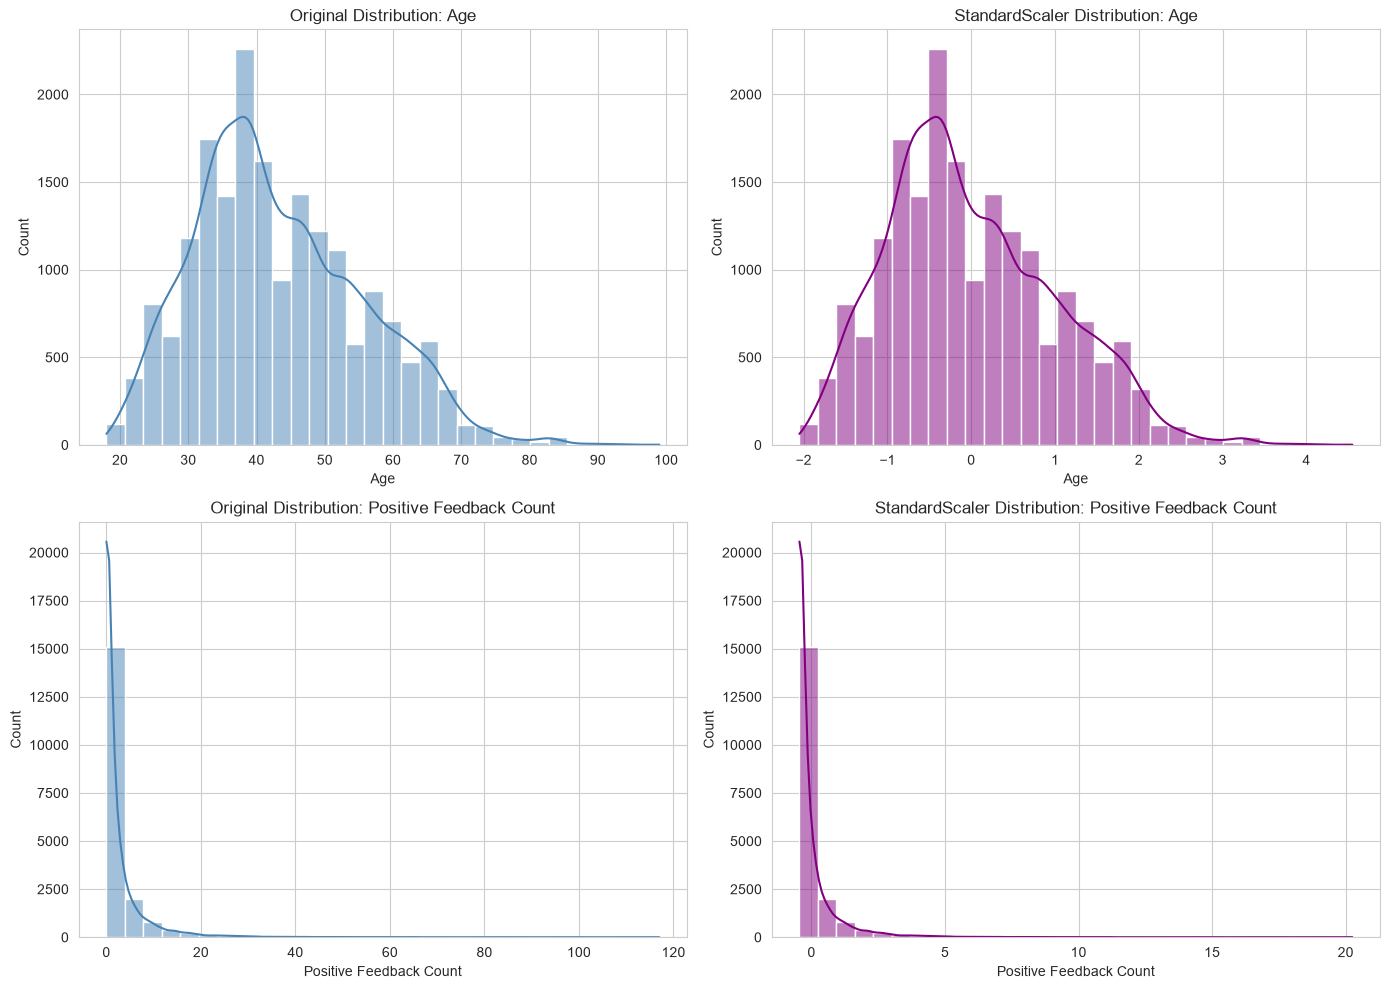

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, column in enumerate(X_train.columns):
    sns.histplot(
        X_train[column],
        bins=30,
        kde=True,
        ax=axes[i, 0],
        color="steelblue"
    )
    axes[i, 0].set_title(f"Original Distribution: {column}")

    sns.histplot(
        X_train_standard[column],
        bins=30,
        kde=True,
        ax=axes[i, 1],
        color="purple"
    )
    axes[i, 1].set_title(f"StandardScaler Distribution: {column}")

plt.tight_layout()
()
plt.show()

In [44]:
standard_skewness_comparison = pd.DataFrame({
    "Original Skewness": X_train.skew(),
    "StandardScaler Skewness": X_train_standard.skew()
})

standard_skewness_comparison

,Original Skewness,StandardScaler Skewness
Age,0.538471,0.538471
Positive Feedback Count,6.117234,6.117234


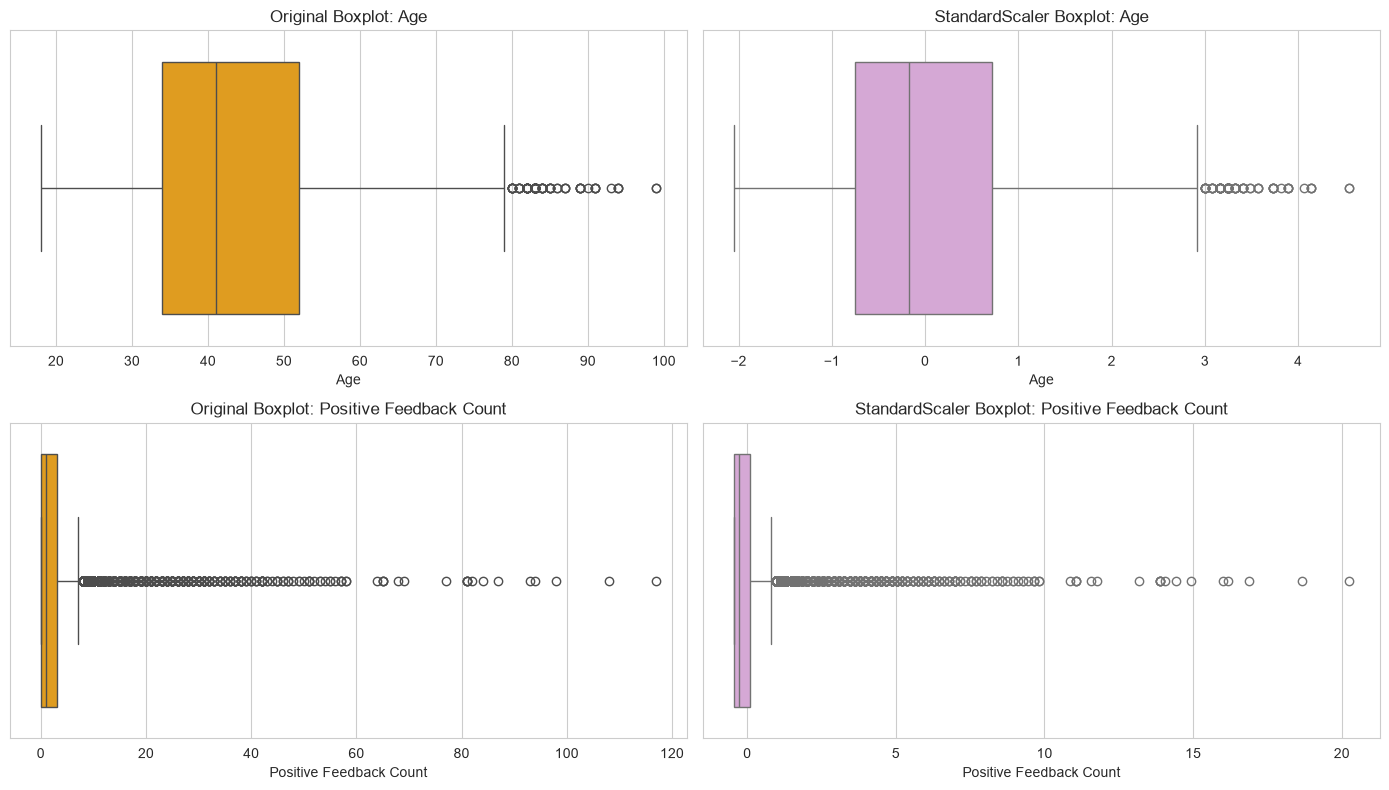

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, column in enumerate(X_train.columns):
    sns.boxplot(
        x=X_train[column],
        ax=axes[i, 0],
        color="orange"
    )
    axes[i, 0].set_title(f"Original Boxplot: {column}")

    sns.boxplot(
        x=X_train_standard[column],
        ax=axes[i, 1],
        color="plum"
    )
    axes[i, 1].set_title(f"StandardScaler Boxplot: {column}")

plt.tight_layout()
plt.show()

In [46]:
robust_scaler = RobustScaler()
X_train_robust_array = robust_scaler.fit_transform(X_train)
X_test_robust_array = robust_scaler.transform(X_test)

In [47]:
X_train_robust = pd.DataFrame(
    X_train_robust_array,
    columns=X_train.columns,
    index=X_train.index
)

X_test_robust = pd.DataFrame(
    X_test_robust_array,
    columns=X_test.columns,
    index=X_test.index
)

X_train_robust.head()

,Age,Positive Feedback Count
22653,0.444444,-0.333333
6939,-0.333333,1.666667
2679,0.444444,-0.333333
17164,-0.722222,-0.333333
714,0.500000,-0.333333


In [48]:
robust_parameters = pd.DataFrame({
    "Feature": X_train.columns,
    "Training Median": robust_scaler.center_,
    "Training IQR": robust_scaler.scale_
})

robust_parameters

,Feature,Training Median,Training IQR
0,Age,41.0,18.0
1,Positive Feedback Count,1.0,3.0


In [49]:
robust_check = pd.DataFrame({
    "Scaled Median": X_train_robust.median(),
    "Scaled Q1": X_train_robust.quantile(0.25),
    "Scaled Q3": X_train_robust.quantile(0.75)
})

robust_check["Scaled IQR"] = (
    robust_check["Scaled Q3"] -
    robust_check["Scaled Q1"]
)

robust_check

,Scaled Median,Scaled Q1,Scaled Q3,Scaled IQR
Age,0.0,-0.388889,0.611111,1.0
Positive Feedback Count,0.0,-0.333333,0.666667,1.0


In [50]:
original_robust_summary = X_train.describe().T[
    ["mean", "std", "min", "50%", "max"]
].add_prefix("Original ")

scaled_robust_summary = X_train_robust.describe().T[
    ["mean", "std", "min", "50%", "max"]
].add_prefix("Robust ")

robust_comparison = pd.concat(
    [original_robust_summary, scaled_robust_summary],
    axis=1
)

robust_comparison

,Original mean,Original std,Original min,Original 50%,Original max,Robust mean,Robust std,Robust min,Robust 50%,Robust max
Age,43.174367,12.275373,18.0,41.0,99.0,0.120798,0.681965,-1.277778,0.0,3.222222
Positive Feedback Count,2.547796,5.651950,0.0,1.0,117.0,0.515932,1.883983,-0.333333,0.0,38.666667


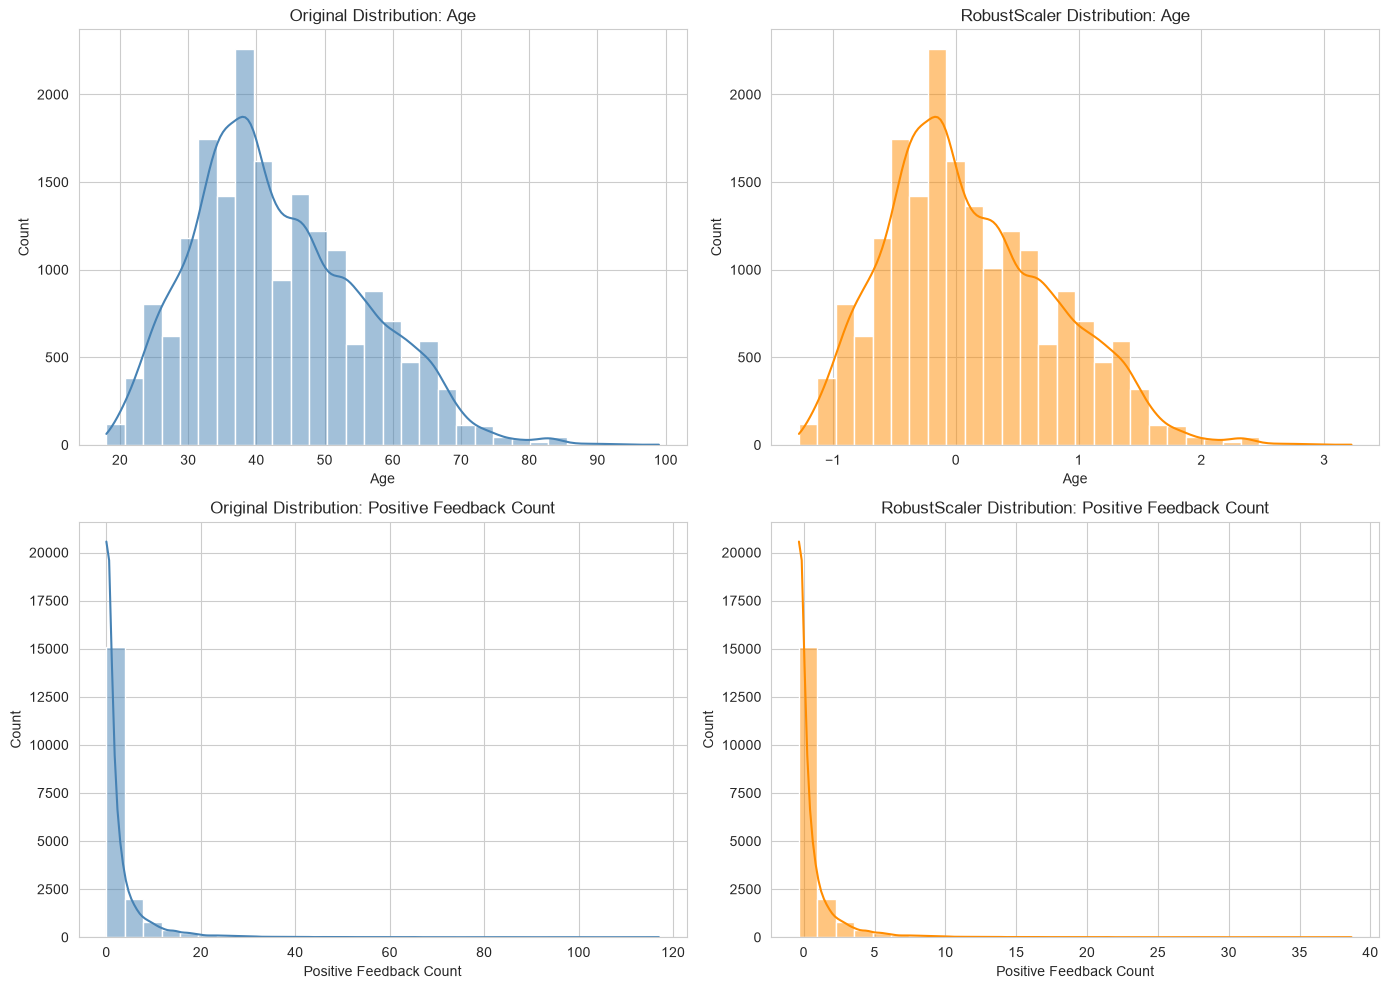

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, column in enumerate(X_train.columns):
    sns.histplot(
        X_train[column],
        bins=30,
        kde=True,
        ax=axes[i, 0],
        color="steelblue"
    )
    axes[i, 0].set_title(f"Original Distribution: {column}")

    sns.histplot(
        X_train_robust[column],
        bins=30,
        kde=True,
        ax=axes[i, 1],
        color="darkorange"
    )
    axes[i, 1].set_title(f"RobustScaler Distribution: {column}")

plt.tight_layout()
plt.show()

In [52]:
robust_skewness_comparison = pd.DataFrame({
    "Original Skewness": X_train.skew(),
    "RobustScaler Skewness": X_train_robust.skew()
})

robust_skewness_comparison

,Original Skewness,RobustScaler Skewness
Age,0.538471,0.538471
Positive Feedback Count,6.117234,6.117234


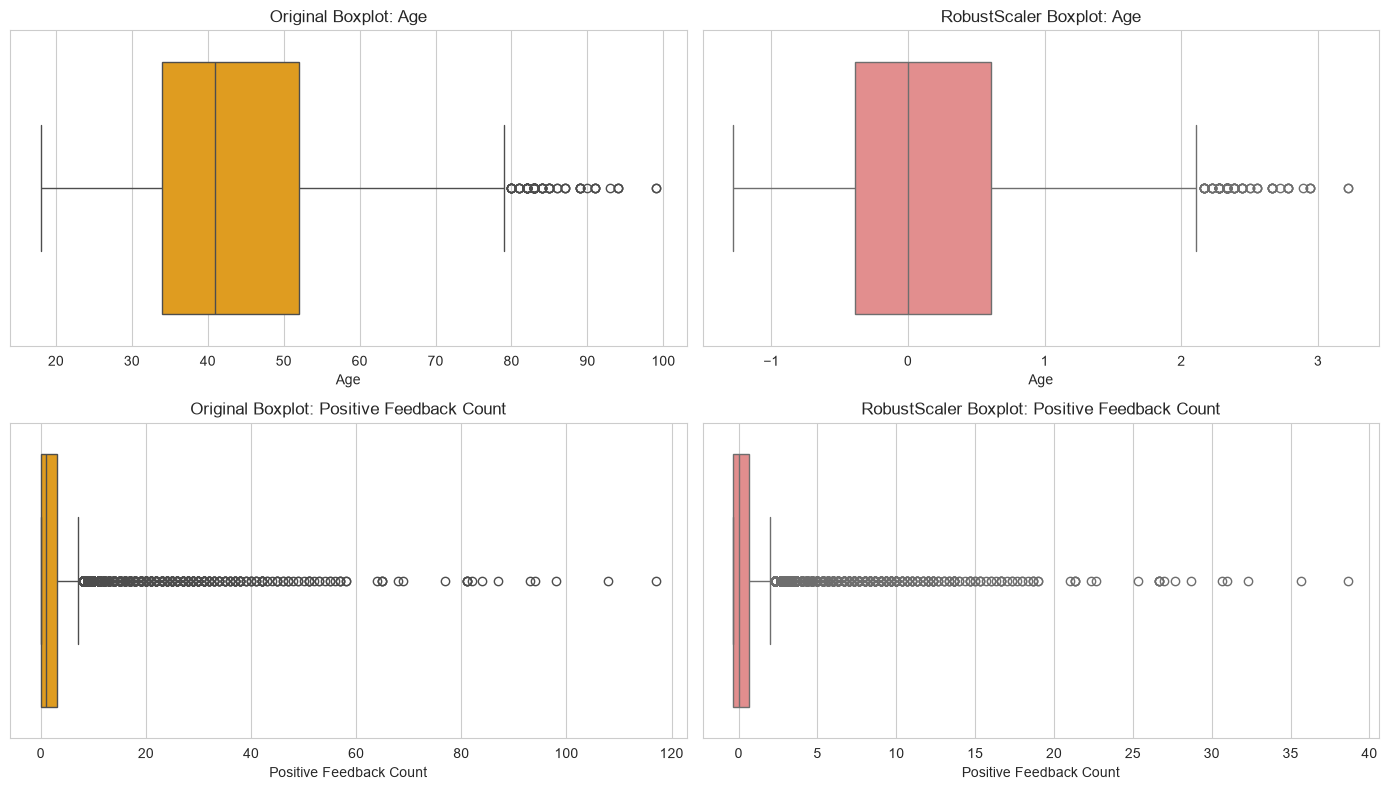

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, column in enumerate(X_train.columns):
    sns.boxplot(
        x=X_train[column],
        ax=axes[i, 0],
        color="orange"
    )
    axes[i, 0].set_title(f"Original Boxplot: {column}")

    sns.boxplot(
        x=X_train_robust[column],
        ax=axes[i, 1],
        color="lightcoral"
    )
    axes[i, 1].set_title(f"RobustScaler Boxplot: {column}")

plt.tight_layout()
plt.show()

In [55]:
power_transformer = PowerTransformer(
    method="yeo-johnson",
    standardize=True
)
X_train_power_array = power_transformer.fit_transform(X_train)
X_test_power_array = power_transformer.transform(X_test)
X_train_power = pd.DataFrame(
    X_train_power_array,
    columns=X_train.columns,
    index=X_train.index
)

X_test_power = pd.DataFrame(
    X_test_power_array,
    columns=X_test.columns,
    index=X_test.index
)

X_train_power.head()

,Age,Positive Feedback Count
22653,0.569492,-0.969982
6939,-0.608183,1.370849
2679,0.569492,-0.969982
17164,-1.354559,-0.969982
714,0.642214,-0.969982


In [56]:
power_parameters = pd.DataFrame({
    "Feature": X_train.columns,
    "Yeo-Johnson Lambda": power_transformer.lambdas_
})

power_parameters

,Feature,Yeo-Johnson Lambda
0,Age,0.138718
1,Positive Feedback Count,-0.710882


In [57]:
power_standardization_check = pd.DataFrame({
    "Scaled Mean": X_train_power.mean(),
    "Scaled Standard Deviation": X_train_power.std(ddof=0),
    "Scaled Minimum": X_train_power.min(),
    "Scaled Maximum": X_train_power.max()
})

power_standardization_check

,Scaled Mean,Scaled Standard Deviation,Scaled Minimum,Scaled Maximum
Age,-1.584615e-16,1.0,-2.751069,3.237669
Positive Feedback Count,-2.080043e-17,1.0,-0.969982,2.049070


In [58]:
power_skewness_comparison = pd.DataFrame({
    "Original Skewness": X_train.skew(),
    "PowerTransformer Skewness": X_train_power.skew()
})

power_skewness_comparison["Absolute Skewness Reduction"] = (
    power_skewness_comparison["Original Skewness"].abs()
    - power_skewness_comparison["PowerTransformer Skewness"].abs()
)

power_skewness_comparison

,Original Skewness,PowerTransformer Skewness,Absolute Skewness Reduction
Age,0.538471,-0.006044,0.532428
Positive Feedback Count,6.117234,0.329661,5.787573


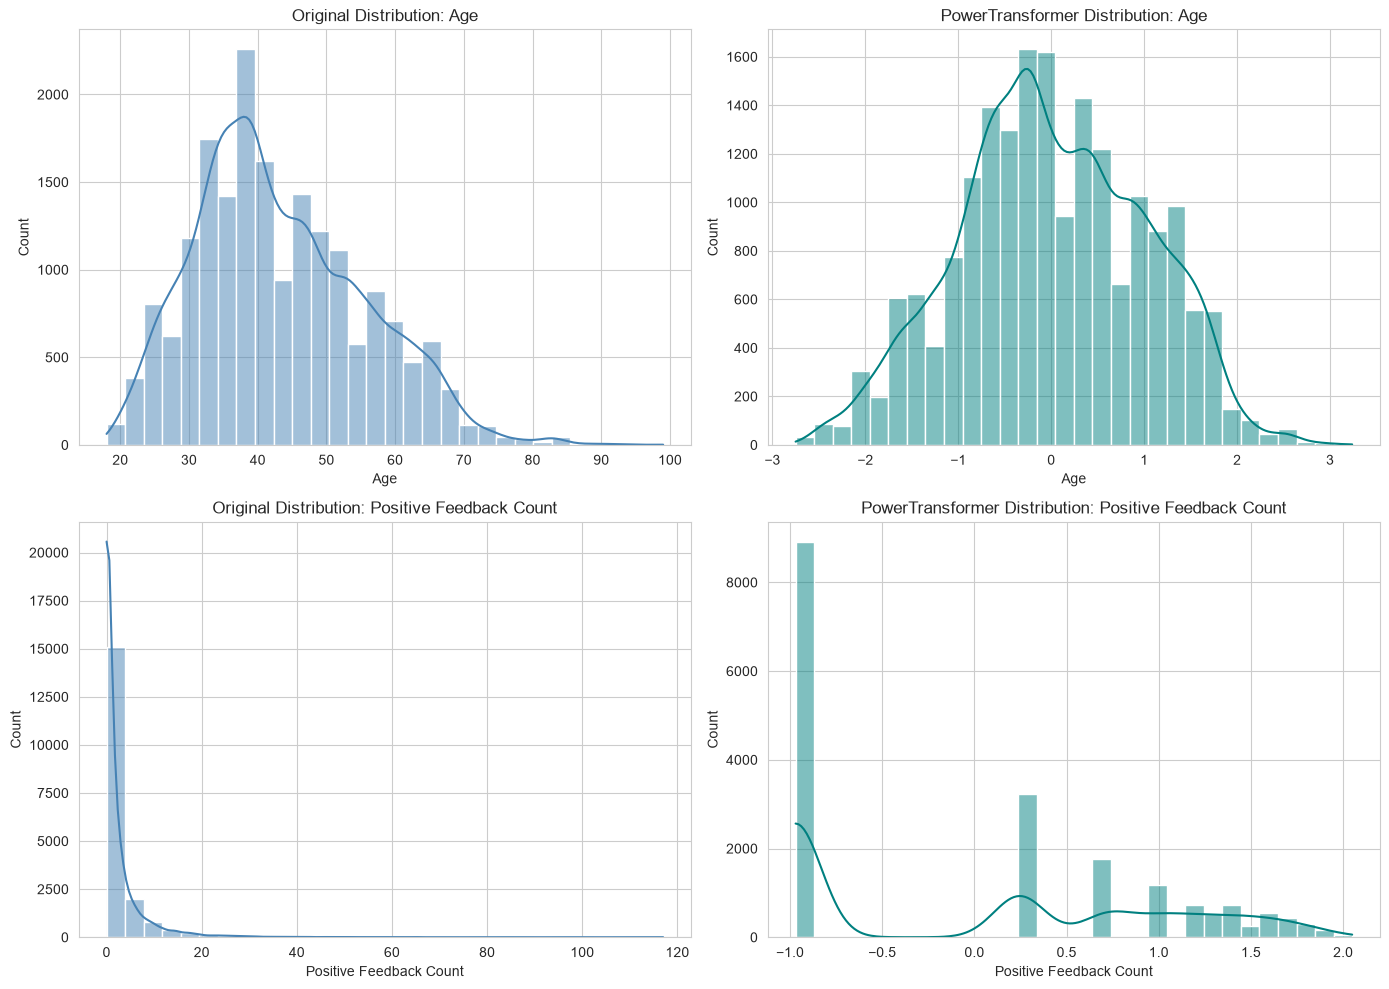

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, column in enumerate(X_train.columns):
    sns.histplot(
        X_train[column],
        bins=30,
        kde=True,
        ax=axes[i, 0],
        color="steelblue"
    )
    axes[i, 0].set_title(f"Original Distribution: {column}")

    sns.histplot(
        X_train_power[column],
        bins=30,
        kde=True,
        ax=axes[i, 1],
        color="teal"
    )
    axes[i, 1].set_title(f"PowerTransformer Distribution: {column}")

plt.tight_layout()
plt.show()

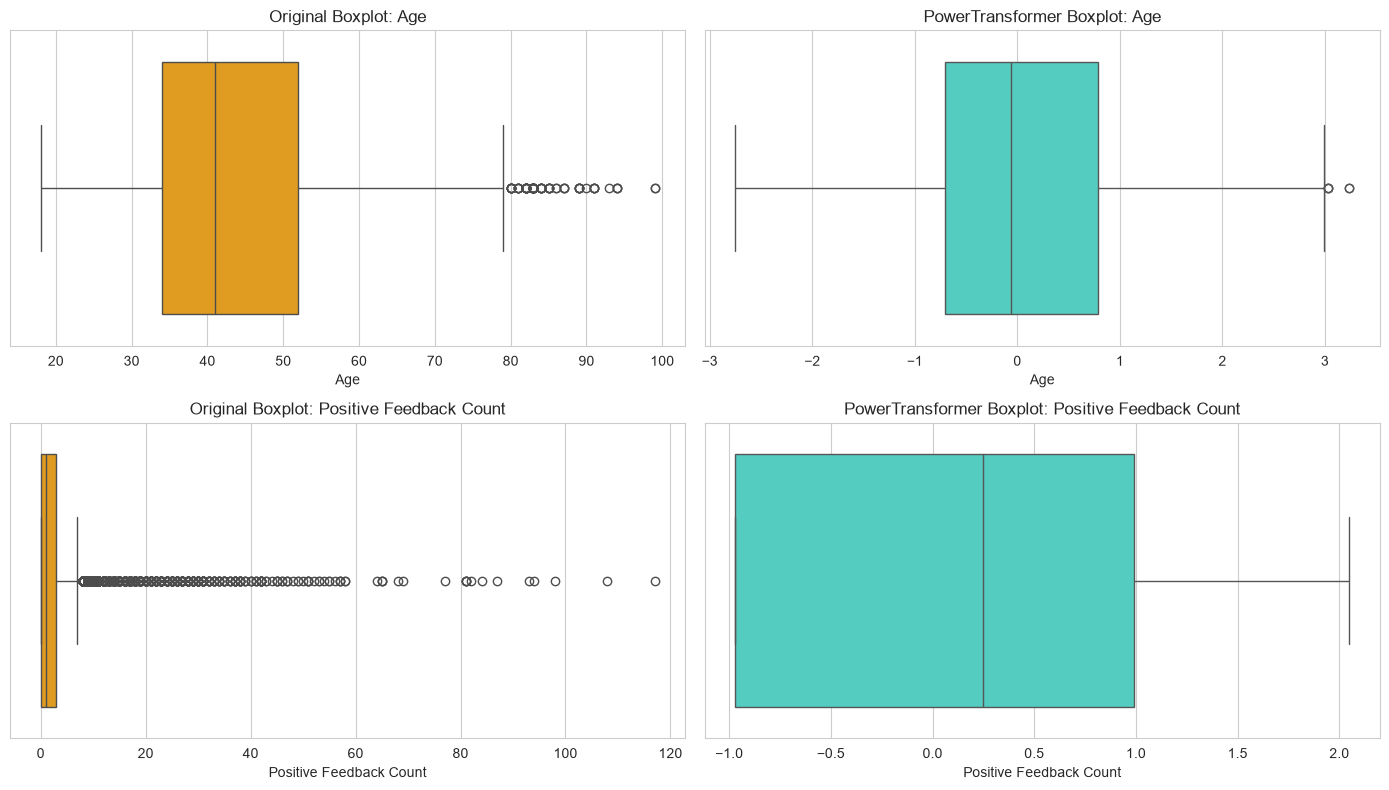

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, column in enumerate(X_train.columns):
    sns.boxplot(
        x=X_train[column],
        ax=axes[i, 0],
        color="orange"
    )
    axes[i, 0].set_title(f"Original Boxplot: {column}")

    sns.boxplot(
        x=X_train_power[column],
        ax=axes[i, 1],
        color="turquoise"
    )
    axes[i, 1].set_title(f"PowerTransformer Boxplot: {column}")

plt.tight_layout()
plt.show()

In [61]:
X_train_power_reversed = power_transformer.inverse_transform(
    X_train_power
)

reversal_check = np.allclose(
    X_train_power_reversed,
    X_train.values
)

print("Transformation successfully reversible:", reversal_check)

Transformation successfully reversible: True


In [63]:
scaled_datasets = {
    "Original": X_train,
    "MinMaxScaler": X_train_minmax,
    "StandardScaler": X_train_standard,
    "RobustScaler": X_train_robust,
    "PowerTransformer": X_train_power
}

print("Datasets prepared for comparison:")
print(list(scaled_datasets.keys()))

Datasets prepared for comparison:
['Original', 'MinMaxScaler', 'StandardScaler', 'RobustScaler', 'PowerTransformer']


In [64]:
comparison_records = []

for method_name, scaled_data in scaled_datasets.items():

    for feature in X_train.columns:
        q1 = scaled_data[feature].quantile(0.25)
        q3 = scaled_data[feature].quantile(0.75)

        comparison_records.append({
            "Method": method_name,
            "Feature": feature,
            "Mean": scaled_data[feature].mean(),
            "Standard Deviation": scaled_data[feature].std(ddof=0),
            "Minimum": scaled_data[feature].min(),
            "Q1": q1,
            "Median": scaled_data[feature].median(),
            "Q3": q3,
            "Maximum": scaled_data[feature].max(),
            "IQR": q3 - q1,
            "Skewness": scaled_data[feature].skew()
        })

scaling_comparison = pd.DataFrame(comparison_records)

scaling_comparison.round(4)

,Method,Feature,Mean,Standard Deviation,Minimum,Q1,Median,Q3,Maximum,IQR,Skewness
0,Original,Age,43.1744,12.2750,18.0000,34.0000,41.0000,52.0000,99.0000,18.0000,0.5385
1,Original,Positive Feedback Count,2.5478,5.6518,0.0000,0.0000,1.0000,3.0000,117.0000,3.0000,6.1172
2,MinMaxScaler,Age,0.3108,0.1515,0.0000,0.1975,0.2840,0.4198,1.0000,0.2222,0.5385
3,MinMaxScaler,Positive Feedback Count,0.0218,0.0483,0.0000,0.0000,0.0085,0.0256,1.0000,0.0256,6.1172
4,StandardScaler,Age,0.0000,1.0000,-2.0509,-0.7474,-0.1771,0.7190,4.5479,1.4664,0.5385
5,StandardScaler,Positive Feedback Count,-0.0000,1.0000,-0.4508,-0.4508,-0.2739,0.0800,20.2506,0.5308,6.1172
6,RobustScaler,Age,0.1208,0.6819,-1.2778,-0.3889,0.0000,0.6111,3.2222,1.0000,0.5385
7,RobustScaler,Positive Feedback Count,0.5159,1.8839,-0.3333,-0.3333,0.0000,0.6667,38.6667,1.0000,6.1172
8,PowerTransformer,Age,-0.0000,1.0000,-2.7511,-0.7067,-0.0622,0.7840,3.2377,1.4907,-0.0060
9,PowerTransformer,Positive Feedback Count,-0.0000,1.0000,-0.9700,-0.9700,0.2455,0.9881,2.0491,1.9581,0.3297


In [65]:
skewness_comparison = pd.DataFrame({
    method_name: scaled_data.skew()
    for method_name, scaled_data in scaled_datasets.items()
})

skewness_comparison.round(4)

,Original,MinMaxScaler,StandardScaler,RobustScaler,PowerTransformer
Age,0.5385,0.5385,0.5385,0.5385,-0.0060
Positive Feedback Count,6.1172,6.1172,6.1172,6.1172,0.3297


In [66]:
absolute_skewness = skewness_comparison.abs()

absolute_skewness.round(4)

,Original,MinMaxScaler,StandardScaler,RobustScaler,PowerTransformer
Age,0.5385,0.5385,0.5385,0.5385,0.0060
Positive Feedback Count,6.1172,6.1172,6.1172,6.1172,0.3297


In [67]:
average_absolute_skewness = (
    absolute_skewness
    .mean()
    .sort_values()
    .to_frame(name="Average Absolute Skewness")
)

average_absolute_skewness.round(4)

,Average Absolute Skewness
PowerTransformer,0.1679
RobustScaler,3.3279
MinMaxScaler,3.3279
Original,3.3279
StandardScaler,3.3279


In [68]:
preservation_records = []

for method_name, scaled_data in scaled_datasets.items():

    if method_name == "Original":
        continue

    for feature in X_train.columns:
        correlation = X_train[feature].corr(
            scaled_data[feature],
            method="pearson"
        )

        preservation_records.append({
            "Method": method_name,
            "Feature": feature,
            "Correlation with Original": correlation
        })

distribution_preservation = pd.DataFrame(
    preservation_records
)

distribution_preservation.round(4)

,Method,Feature,Correlation with Original
0,MinMaxScaler,Age,1.0000
1,MinMaxScaler,Positive Feedback Count,1.0000
2,StandardScaler,Age,1.0000
3,StandardScaler,Positive Feedback Count,1.0000
4,RobustScaler,Age,1.0000
5,RobustScaler,Positive Feedback Count,1.0000
6,PowerTransformer,Age,0.9893
7,PowerTransformer,Positive Feedback Count,0.6410


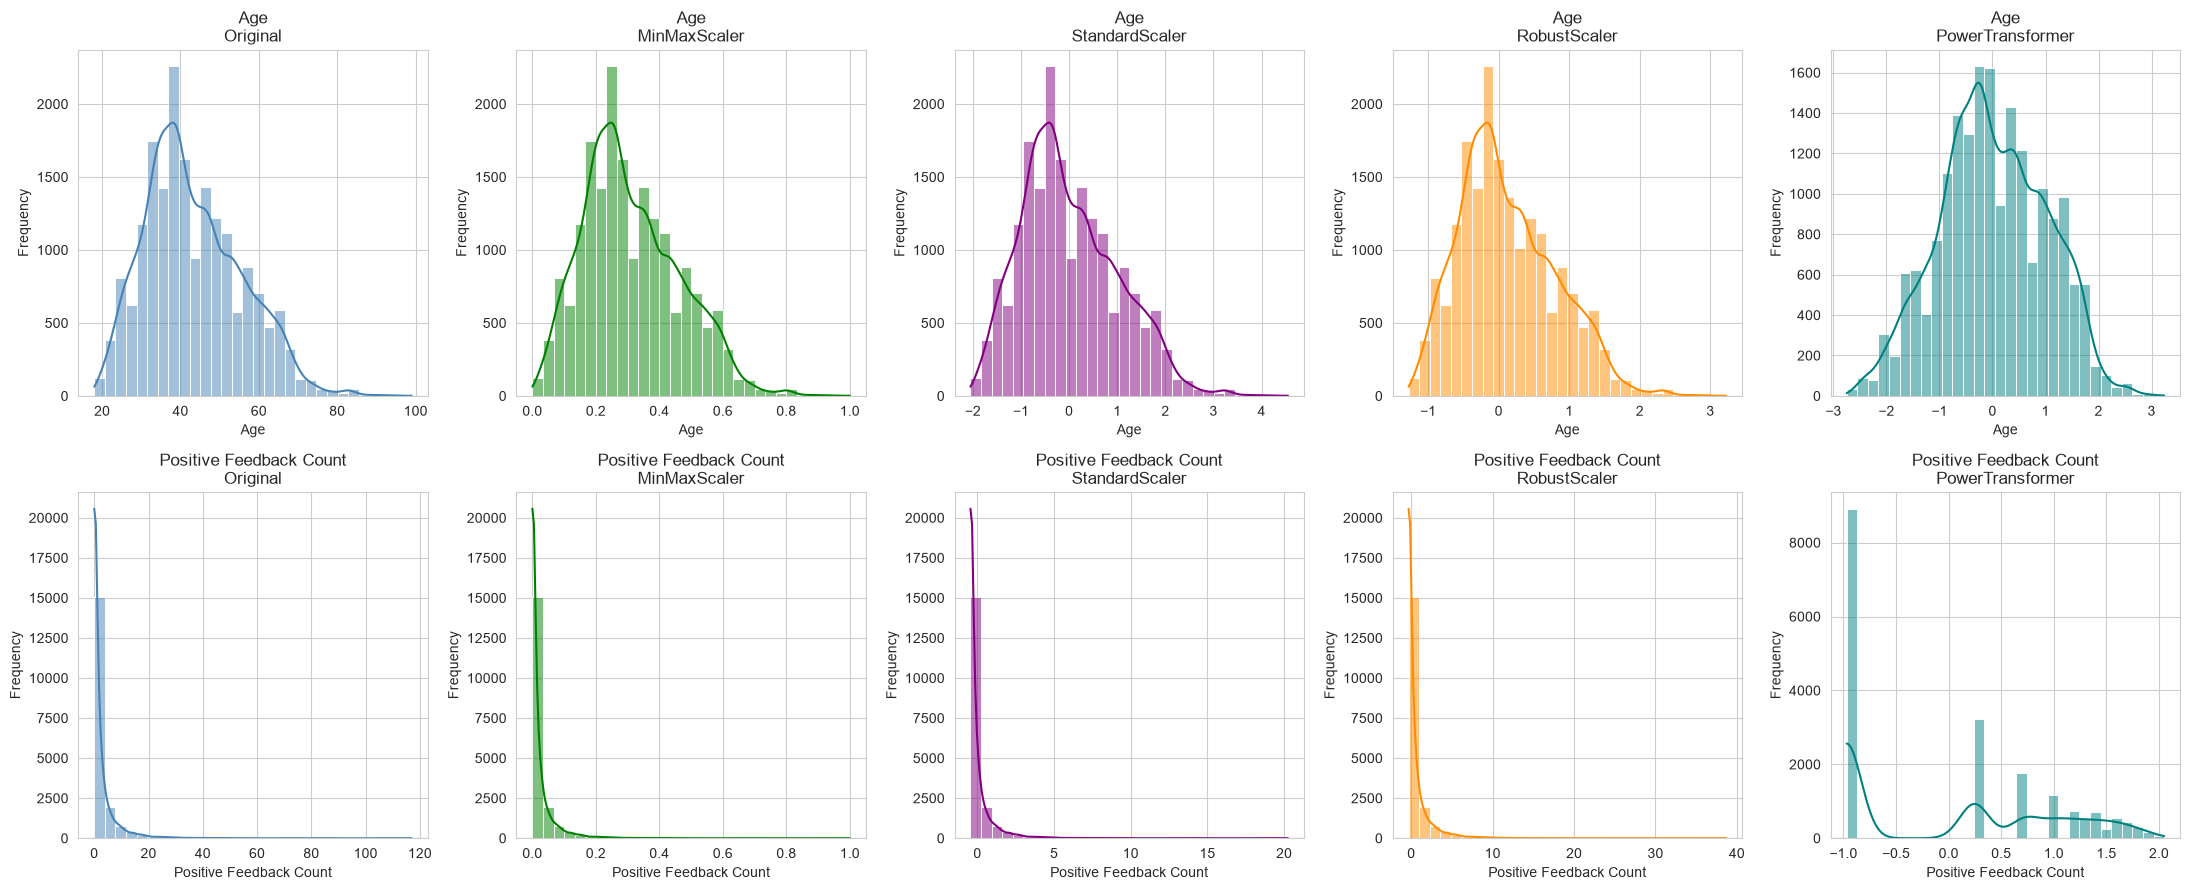

In [69]:
method_colors = {
    "Original": "steelblue",
    "MinMaxScaler": "green",
    "StandardScaler": "purple",
    "RobustScaler": "darkorange",
    "PowerTransformer": "teal"
}

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(22, 9)
)

for row_index, feature in enumerate(X_train.columns):

    for column_index, (method_name, scaled_data) in enumerate(
        scaled_datasets.items()
    ):
        sns.histplot(
            scaled_data[feature],
            bins=30,
            kde=True,
            ax=axes[row_index, column_index],
            color=method_colors[method_name]
        )

        axes[row_index, column_index].set_title(
            f"{feature}\n{method_name}"
        )
        axes[row_index, column_index].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

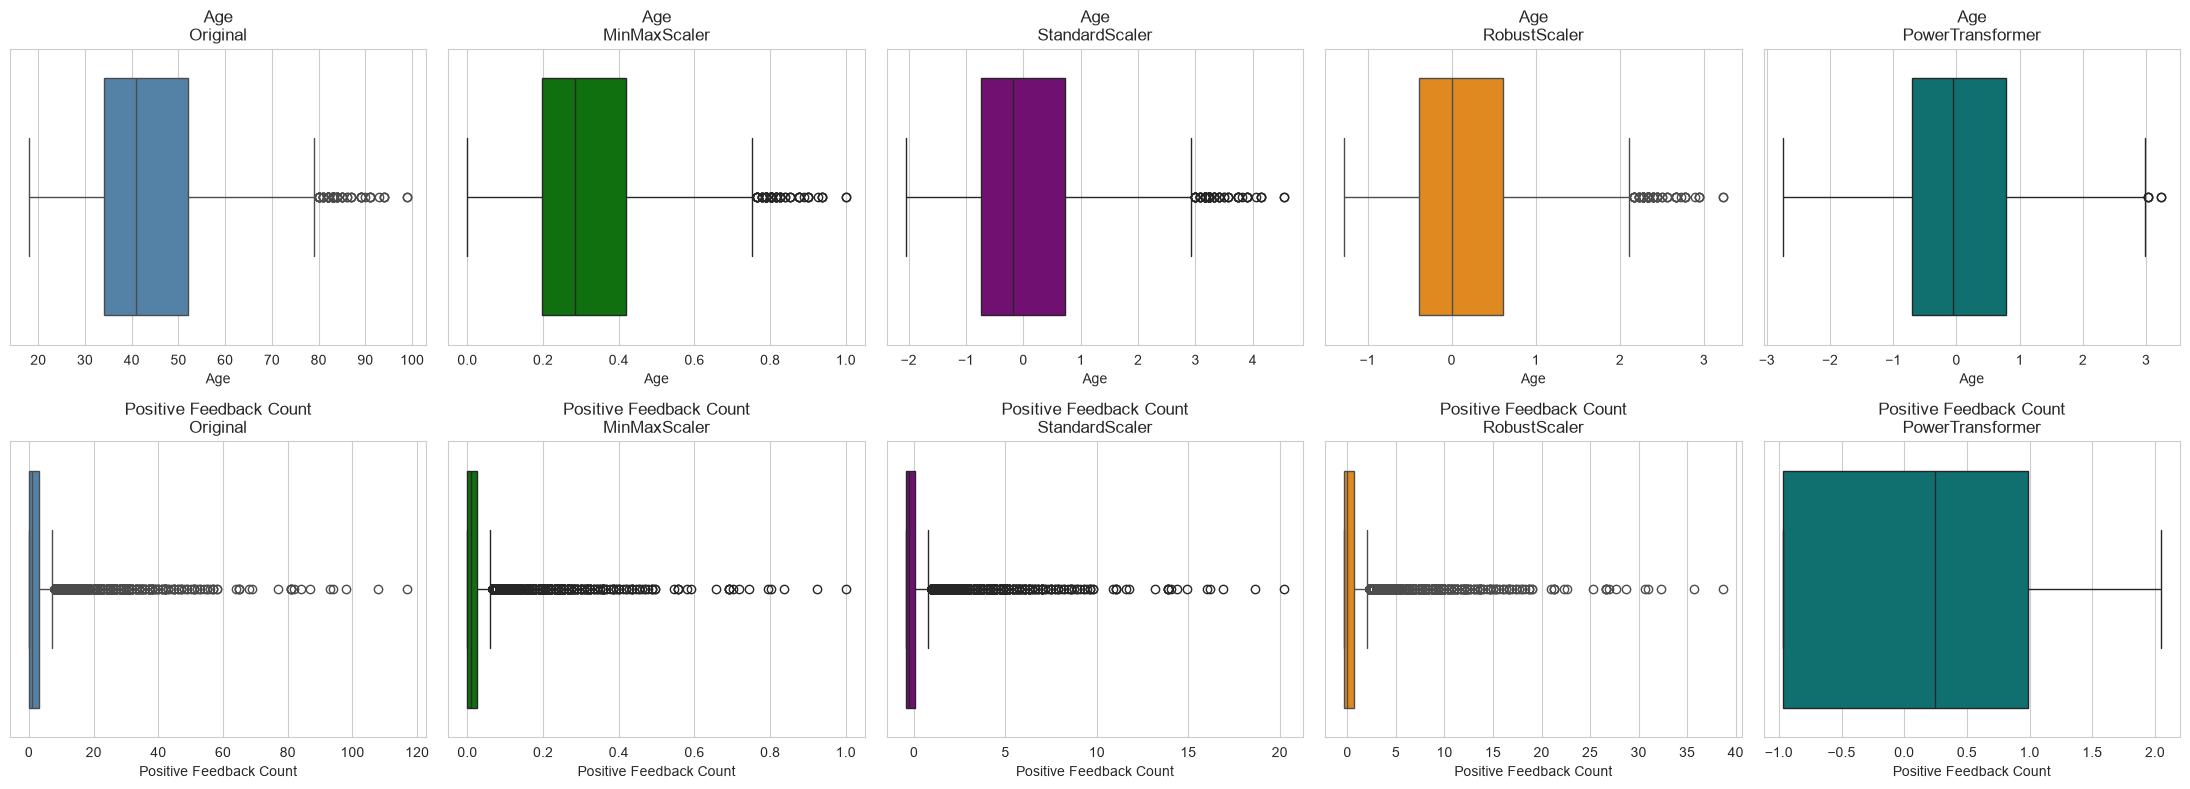

In [70]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(22, 8)
)

for row_index, feature in enumerate(X_train.columns):

    for column_index, (method_name, scaled_data) in enumerate(
        scaled_datasets.items()
    ):
        sns.boxplot(
            x=scaled_data[feature],
            ax=axes[row_index, column_index],
            color=method_colors[method_name]
        )

        axes[row_index, column_index].set_title(
            f"{feature}\n{method_name}"
        )

plt.tight_layout()
plt.show()

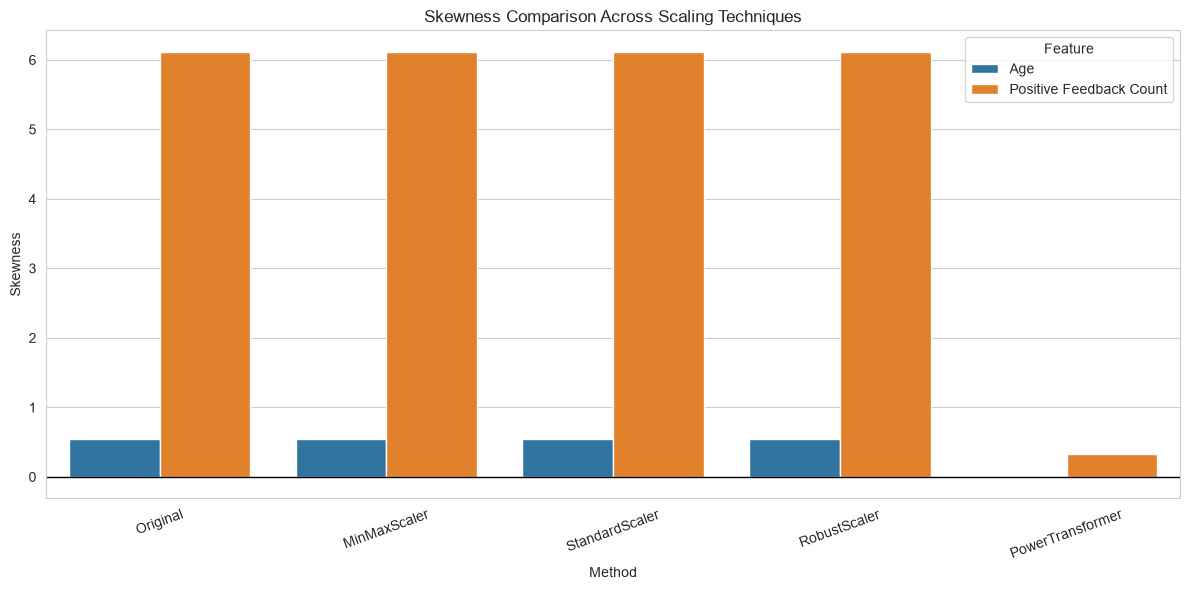

In [71]:
skewness_plot_data = (
    skewness_comparison
    .reset_index()
    .rename(columns={"index": "Feature"})
    .melt(
        id_vars="Feature",
        var_name="Method",
        value_name="Skewness"
    )
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=skewness_plot_data,
    x="Method",
    y="Skewness",
    hue="Feature"
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Skewness Comparison Across Scaling Techniques")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [73]:
scaling_methods = {
    "Original": "passthrough",

    "MinMaxScaler": MinMaxScaler(),

    "StandardScaler": StandardScaler(),

    "RobustScaler": RobustScaler(),

    "PowerTransformer": PowerTransformer(
        method="yeo-johnson",
        standardize=True
    )
}

In [74]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [75]:
cv_scoring = {
    "weighted_f1": "f1_weighted",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc"
}

In [76]:
model_results = []
trained_pipelines = {}

for method_name, scaler in scaling_methods.items():

    pipeline = Pipeline([
        ("scaler", scaler),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_probability = pipeline.predict_proba(X_test)[:, 1]

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=cv_scoring,
        n_jobs=-1
    )

    trained_pipelines[method_name] = pipeline

    model_results.append({
        "Method": method_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),

        "Weighted Precision": precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Weighted Recall": recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_probability
        ),

        "CV Weighted F1 Mean":
            cv_results["test_weighted_f1"].mean(),

        "CV Weighted F1 Std":
            cv_results["test_weighted_f1"].std(),

        "CV Balanced Accuracy Mean":
            cv_results["test_balanced_accuracy"].mean(),

        "CV ROC-AUC Mean":
            cv_results["test_roc_auc"].mean()
    })

In [77]:
performance_comparison = pd.DataFrame(
    model_results
)

performance_comparison = performance_comparison.sort_values(
    by=[
        "CV Weighted F1 Mean",
        "Balanced Accuracy"
    ],
    ascending=False
).reset_index(drop=True)

performance_comparison.round(4)

,Method,Accuracy,Balanced Accuracy,Weighted Precision,Weighted Recall,Weighted F1,ROC-AUC,CV Weighted F1 Mean,CV Weighted F1 Std,CV Balanced Accuracy Mean,CV ROC-AUC Mean
0,Original,0.7752,0.5010,0.7086,0.7752,0.7355,0.5107,0.7423,0.0054,0.5047,0.5158
1,MinMaxScaler,0.7720,0.4981,0.7059,0.7720,0.7331,0.5158,0.7422,0.0025,0.5038,0.5113
2,RobustScaler,0.7986,0.5058,0.7164,0.7986,0.7441,0.5302,0.7397,0.0020,0.5024,0.5102
3,PowerTransformer,0.7927,0.5031,0.7118,0.7927,0.7412,0.5244,0.7388,0.0024,0.5028,0.5098
4,StandardScaler,0.7893,0.5025,0.7107,0.7893,0.7400,0.5177,0.7382,0.0029,0.5025,0.5082


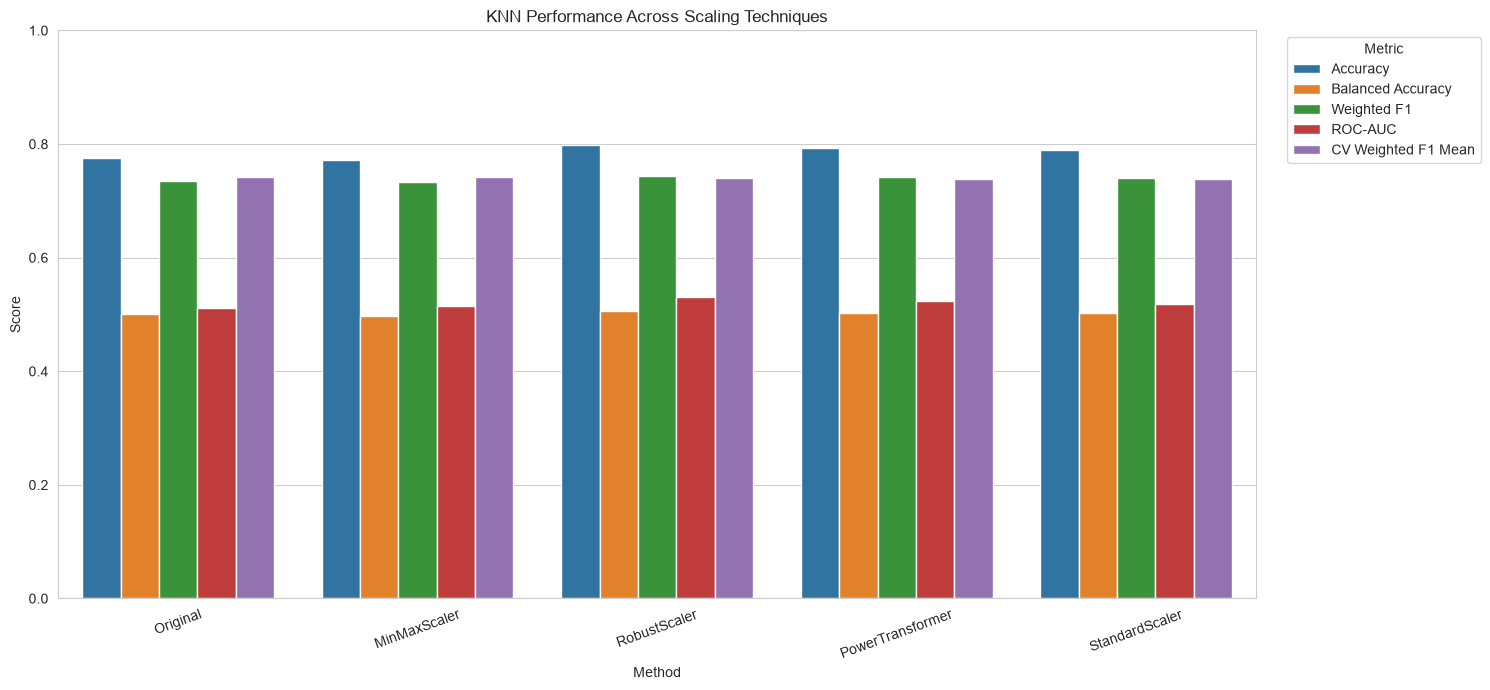

In [78]:
plot_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Weighted F1",
    "ROC-AUC",
    "CV Weighted F1 Mean"
]

performance_plot_data = performance_comparison[
    ["Method"] + plot_columns
].melt(
    id_vars="Method",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(15, 7))

sns.barplot(
    data=performance_plot_data,
    x="Method",
    y="Score",
    hue="Metric"
)

plt.title("KNN Performance Across Scaling Techniques")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [79]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

dummy_prediction = dummy_model.predict(X_test)
dummy_probability = dummy_model.predict_proba(X_test)[:, 1]

dummy_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Weighted F1",
        "ROC-AUC"
    ],

    "Dummy Baseline Score": [
        accuracy_score(y_test, dummy_prediction),
        balanced_accuracy_score(y_test, dummy_prediction),

        f1_score(
            y_test,
            dummy_prediction,
            average="weighted",
            zero_division=0
        ),

        roc_auc_score(
            y_test,
            dummy_probability
        )
    ]
})

dummy_results.round(4)

,Metric,Dummy Baseline Score
0,Accuracy,0.8223
1,Balanced Accuracy,0.5000
2,Weighted F1,0.7421
3,ROC-AUC,0.5000


In [80]:
best_model_method = performance_comparison.iloc[0]["Method"]

print(
    "Best method based on CV Weighted F1:",
    best_model_method
)

Best method based on CV Weighted F1: Original


In [81]:
scaled_methods_results = performance_comparison[
    performance_comparison["Method"] != "Original"
].copy()

scaled_methods_results = scaled_methods_results.sort_values(
    by=[
        "CV Weighted F1 Mean",
        "Balanced Accuracy",
        "ROC-AUC"
    ],
    ascending=False
).reset_index(drop=True)

best_scaler_method = scaled_methods_results.iloc[0]["Method"]

print(
    "Best scaling technique:",
    best_scaler_method
)

scaled_methods_results.round(4)

Best scaling technique: MinMaxScaler


,Method,Accuracy,Balanced Accuracy,Weighted Precision,Weighted Recall,Weighted F1,ROC-AUC,CV Weighted F1 Mean,CV Weighted F1 Std,CV Balanced Accuracy Mean,CV ROC-AUC Mean
0,MinMaxScaler,0.7720,0.4981,0.7059,0.7720,0.7331,0.5158,0.7422,0.0025,0.5038,0.5113
1,RobustScaler,0.7986,0.5058,0.7164,0.7986,0.7441,0.5302,0.7397,0.0020,0.5024,0.5102
2,PowerTransformer,0.7927,0.5031,0.7118,0.7927,0.7412,0.5244,0.7388,0.0024,0.5028,0.5098
3,StandardScaler,0.7893,0.5025,0.7107,0.7893,0.7400,0.5177,0.7382,0.0029,0.5025,0.5082


In [82]:
best_overall_method = performance_comparison.iloc[0]["Method"]

print("Best overall model input:", best_overall_method)
print("Best scaling technique:", best_scaler_method)

Best overall model input: Original
Best scaling technique: MinMaxScaler


In [83]:
final_selection_summary = pd.DataFrame({
    "Selection Type": [
        "Best Overall Input",
        "Best Required Scaling Technique"
    ],

    "Selected Method": [
        best_overall_method,
        best_scaler_method
    ],

    "Reason": [
        "Highest CV Weighted F1 among all inputs",
        "Highest CV Weighted F1 among the four scaling techniques"
    ]
})

final_selection_summary

,Selection Type,Selected Method,Reason
0,Best Overall Input,Original,Highest CV Weighted F1 among all inputs
1,Best Required Scaling Technique,MinMaxScaler,Highest CV Weighted F1 among the four scaling ...


In [84]:
final_scaler_options = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "PowerTransformer": PowerTransformer(
        method="yeo-johnson",
        standardize=True
    )
}

final_scaler = final_scaler_options[
    best_scaler_method
]

print("Final scaler selected:", best_scaler_method)

Final scaler selected: MinMaxScaler


In [85]:
final_scaled_df = df.copy()

print("Original shape:", df.shape)
print("Final copy shape:", final_scaled_df.shape)

Original shape: (23486, 11)
Final copy shape: (23486, 11)


In [86]:
final_scaled_df[scaling_features] = (
    final_scaler.fit_transform(
        df[scaling_features]
    )
)

final_scaled_df.head()

,no,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,0.185185,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0.000000,Initmates,Intimate,Intimates
1,1,1080,0.197531,NaN,Love this dress! it's sooo pretty. i happene...,5,1,0.032787,General,Dresses,Dresses
2,2,1077,0.518519,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0.000000,General,Dresses,Dresses
3,3,1049,0.395062,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0.000000,General Petite,Bottoms,Pants
4,4,847,0.358025,Flattering shirt,This shirt is very flattering to all due to th...,5,1,0.049180,General,Tops,Blouses


In [87]:
final_range_check = pd.DataFrame({
    "Minimum": final_scaled_df[
        scaling_features
    ].min(),

    "Maximum": final_scaled_df[
        scaling_features
    ].max(),

    "Mean": final_scaled_df[
        scaling_features
    ].mean(),

    "Skewness": final_scaled_df[
        scaling_features
    ].skew()
})

final_range_check.round(4)

,Minimum,Maximum,Mean,Skewness
Age,0.0,1.0,0.3111,0.5256
Positive Feedback Count,0.0,1.0,0.0208,6.4730


In [88]:
print("Missing values in scaled features:")

print(
    final_scaled_df[
        scaling_features
    ].isnull().sum()
)

Missing values in scaled features:
Age                        0
Positive Feedback Count    0
dtype: int64


In [89]:
final_value_comparison = pd.DataFrame({
    "Original Age": df["Age"].head(10),
    "Scaled Age": final_scaled_df["Age"].head(10),

    "Original Feedback":
        df["Positive Feedback Count"].head(10),

    "Scaled Feedback":
        final_scaled_df[
            "Positive Feedback Count"
        ].head(10)
})

final_value_comparison

,Original Age,Scaled Age,Original Feedback,Scaled Feedback
0,33,0.185185,0,0.000000
1,34,0.197531,4,0.032787
2,60,0.518519,0,0.000000
3,50,0.395062,0,0.000000
4,47,0.358025,6,0.049180
5,49,0.382716,4,0.032787
6,39,0.259259,1,0.008197
7,39,0.259259,4,0.032787
8,24,0.074074,0,0.000000
9,34,0.197531,0,0.000000


In [90]:
final_scaled_df.to_csv(
    "womens_clothing_minmax_scaled.csv",
    index=False
)

print("Final scaled dataset saved successfully")

Final scaled dataset saved successfully


In [91]:
performance_comparison.to_csv(
    "scaling_model_performance_comparison.csv",
    index=False
)

print("Performance comparison saved successfully")

Performance comparison saved successfully


In [92]:
scaling_comparison.to_csv(
    "scaling_statistical_comparison.csv",
    index=False
)

print("Statistical comparison saved successfully")

Statistical comparison saved successfully


In [93]:
final_selection_summary.to_csv(
    "scaler_selection_summary.csv",
    index=False
)

print("Scaler selection summary saved successfully")

Scaler selection summary saved successfully


In [94]:
output_files = [
    "womens_clothing_minmax_scaled.csv",
    "scaling_model_performance_comparison.csv",
    "scaling_statistical_comparison.csv",
    "scaler_selection_summary.csv"
]

for file_name in output_files:
    print(
        file_name,
        "->",
        "Saved" if os.path.exists(file_name) else "Not saved"
    )

womens_clothing_minmax_scaled.csv -> Saved
scaling_model_performance_comparison.csv -> Saved
scaling_statistical_comparison.csv -> Saved
scaler_selection_summary.csv -> Saved


In [95]:
verified_df = pd.read_csv(
    "womens_clothing_minmax_scaled.csv"
)

print("Saved dataset loaded successfully")
print("Dataset shape:", verified_df.shape)

Saved dataset loaded successfully
Dataset shape: (23486, 11)


In [96]:
verified_df[scaling_features].agg(
    ["min", "max", "mean"]
).round(4)

,Age,Positive Feedback Count
min,0.0000,0.0000
max,1.0000,1.0000
mean,0.3111,0.0208


In [97]:
invalid_value_check = pd.DataFrame({
    "Missing Values":
        verified_df[scaling_features].isnull().sum(),

    "Infinite Values":
        np.isinf(
            verified_df[scaling_features]
        ).sum()
})

invalid_value_check

,Missing Values,Infinite Values
Age,0,0
Positive Feedback Count,0,0


In [98]:
range_validation = {}

for column in scaling_features:
    valid_range = verified_df[column].between(
        0,
        1,
        inclusive="both"
    ).all()

    range_validation[column] = valid_range

print("Range validation:")
print(range_validation)

Range validation:
{'Age': np.True_, 'Positive Feedback Count': np.True_}


In [99]:
non_scaled_columns = [
    column for column in df.columns
    if column not in scaling_features
]

non_scaled_columns_unchanged = (
    verified_df[non_scaled_columns]
    .equals(df[non_scaled_columns])
)

print(
    "Non-scaled columns unchanged:",
    non_scaled_columns_unchanged
)

Non-scaled columns unchanged: True


In [100]:
final_validation_summary = pd.DataFrame({
    "Validation Check": [
        "Row count preserved",
        "Column count preserved",
        "Age range valid",
        "Positive Feedback Count range valid",
        "No missing values introduced in scaled features",
        "No infinite values introduced",
        "Non-scaled columns unchanged"
    ],

    "Status": [
        len(verified_df) == len(df),
        len(verified_df.columns) == len(df.columns),
        verified_df["Age"].between(0, 1).all(),
        verified_df["Positive Feedback Count"].between(0, 1).all(),
        verified_df[scaling_features].isnull().sum().sum() == 0,
        np.isinf(verified_df[scaling_features]).sum().sum() == 0,
        non_scaled_columns_unchanged
    ]
})

final_validation_summary

,Validation Check,Status
0,Row count preserved,True
1,Column count preserved,True
2,Age range valid,True
3,Positive Feedback Count range valid,True
4,No missing values introduced in scaled features,True
5,No infinite values introduced,True
6,Non-scaled columns unchanged,True


In [101]:
final_validation_summary.to_csv(
    "scaling_validation_summary.csv",
    index=False
)

print("Final validation summary saved successfully")

Final validation summary saved successfully
